In [17]:
import pandas as pd
import re
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from bertopic import BERTopic
from sklearn.feature_extraction.text import TfidfVectorizer

In [18]:
# Encode target labels
df_clean = pd.read_csv('df_clean.csv')
df_clean['label'] = df_clean['class'].map({'non-suicide': 0, 'suicide': 1})

In [19]:
# Remove any null or empty text rows
df_clean = df_clean[df_clean['text_clean_deep'].notnull()]
df_clean = df_clean[df_clean['text_clean_deep'].str.strip() != ""]

In [20]:
# Define features and target
X = df_clean['text_clean_deep']
y = df_clean['label']

In [21]:
# Train/test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [22]:
print("X_train size:", X_train.shape)
print("X_test size:", X_test.shape)
print("y_train size:", y_train.shape)
print("y_test size:", y_test.shape)

X_train size: (7796,)
X_test size: (1949,)
y_train size: (7796,)
y_test size: (1949,)


In [23]:
 # TF-IDF using unigrams
tfidf_uni = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    ngram_range=(1, 1)
)

X_train_tfidf_uni = tfidf_uni.fit_transform(X_train)
X_test_tfidf_uni = tfidf_uni.transform(X_test)

print("\nUnigram TF-IDF:")
print("Training matrix shape:", X_train_tfidf_uni.shape)
print("Testing matrix shape:", X_test_tfidf_uni.shape)


Unigram TF-IDF:
Training matrix shape: (7796, 5000)
Testing matrix shape: (1949, 5000)


In [24]:
# TF-IDF using unigrams and bigrams
tfidf_bi = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    ngram_range=(1, 2)
)

X_train_tfidf_bi = tfidf_bi.fit_transform(X_train)
X_test_tfidf_bi = tfidf_bi.transform(X_test)

In [25]:
print("\nUnigram + Bigram TF-IDF:")
print("Training matrix shape:", X_train_tfidf_bi.shape)
print("Testing matrix shape:", X_test_tfidf_bi.shape)


Unigram + Bigram TF-IDF:
Training matrix shape: (7796, 5000)
Testing matrix shape: (1949, 5000)


In [26]:
# Show some example features
uni_features = tfidf_uni.get_feature_names_out()
bi_features = tfidf_bi.get_feature_names_out()

In [27]:
print("\nSample unigram features:")
print(uni_features[:20])


Sample unigram features:
['100x' '10th' '10x' '11th' '12th' '13th' '14m' '14th' '15m' '16f' '16m'
 '17f' '17m' '18th' '19th' '1am' '1k' '1st' '20' '20th']


In [28]:
print("\nSample unigram + bigram features:")
print(bi_features[:20])


Sample unigram + bigram features:
['10th' '1st' '20' '2nd' '3rd' '4th' '6th' '7th' '7th grade' '8th' '9th'
 'abandon' 'ability' 'able' 'able make' 'able talk' 'abroad' 'absolute'
 'absolutely' 'abt']


##Train SVC model with mostly default hyperparameters

In [29]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

In [30]:
# Instantiate SVC model with mostly default hyperparameters
clf = SVC(probability=True, random_state=42)
clf.get_params()

{'C': 1.0,
 'break_ties': False,
 'cache_size': 200,
 'class_weight': None,
 'coef0': 0.0,
 'decision_function_shape': 'ovr',
 'degree': 3,
 'gamma': 'scale',
 'kernel': 'rbf',
 'max_iter': -1,
 'probability': True,
 'random_state': 42,
 'shrinking': True,
 'tol': 0.001,
 'verbose': False}

In [31]:
%%time

# Train model with tfidf features
clf.fit(X_train_tfidf_uni, y_train)

CPU times: total: 24.7 s
Wall time: 24.9 s


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [32]:
# Tried Saving a Trained Model - models are saved using joblib instead of CSV since CSV cannot store trained models

# import joblib

# # Save model + vectorizer to avoid retraining (takes long)
# joblib.dump(clf, "svc_model.pkl")
# joblib.dump(tfidf_uni, "tfidf_uni_vectorizer.pkl")

# print("Saved successfully")

In [33]:
%%time

# Display accuracy
predictions = clf.predict(X_test_tfidf_uni)
accuracy = round(accuracy_score(y_test, predictions)*100,3)
print(f"SVC Accuracy = {accuracy}%")

SVC Accuracy = 90.918%
CPU times: total: 1.06 s
Wall time: 1.05 s


In [34]:
# Display classification report
print("SVC Classification report")
print(classification_report(y_test,predictions))

SVC Classification report
              precision    recall  f1-score   support

           0       0.88      0.94      0.91       947
           1       0.94      0.88      0.91      1002

    accuracy                           0.91      1949
   macro avg       0.91      0.91      0.91      1949
weighted avg       0.91      0.91      0.91      1949



SVC Confusion matrix


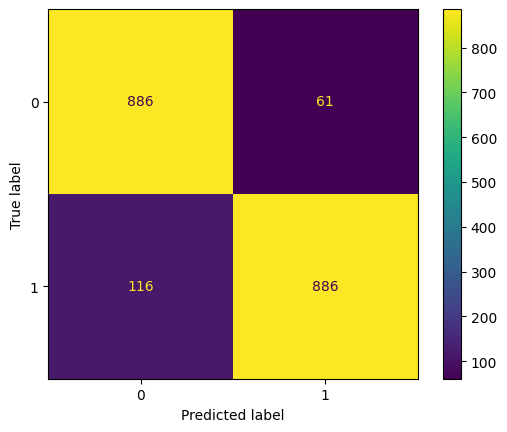

In [35]:
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(y_test, predictions)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

print("SVC Confusion matrix")
plt.show()

### Try SVC again with Unigrams and Bigrams

In [36]:
# Instantiate a second SVC model with mostly default hyperparameters
clf2 = SVC(probability=True, random_state=42)
clf2.get_params()

{'C': 1.0,
 'break_ties': False,
 'cache_size': 200,
 'class_weight': None,
 'coef0': 0.0,
 'decision_function_shape': 'ovr',
 'degree': 3,
 'gamma': 'scale',
 'kernel': 'rbf',
 'max_iter': -1,
 'probability': True,
 'random_state': 42,
 'shrinking': True,
 'tol': 0.001,
 'verbose': False}

In [37]:
%%time

# Train model with tfidf features
clf2.fit(X_train_tfidf_bi, y_train)

CPU times: total: 29.9 s
Wall time: 30.2 s


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [38]:
%%time

# Display accuracy
predictions2 = clf2.predict(X_test_tfidf_bi)
accuracy2 = round(accuracy_score(y_test, predictions2)*100,3)
print(f"SVC Accuracy = {accuracy2}%")

SVC Accuracy = 91.021%
CPU times: total: 1.62 s
Wall time: 1.64 s


In [39]:
# Display classification report
print("SVC Classification report")
print(classification_report(y_test,predictions2))

SVC Classification report
              precision    recall  f1-score   support

           0       0.89      0.93      0.91       947
           1       0.93      0.89      0.91      1002

    accuracy                           0.91      1949
   macro avg       0.91      0.91      0.91      1949
weighted avg       0.91      0.91      0.91      1949



SVC Confusion matrix


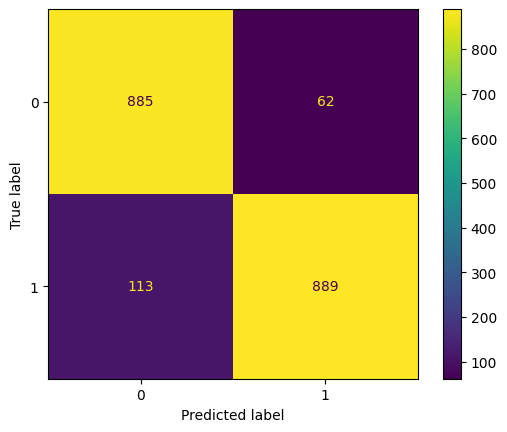

In [40]:
# Compute confusion matrix
cm = confusion_matrix(y_test, predictions2)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

print("SVC Confusion matrix")
plt.show()

##Train Naive Bayes model

In [41]:
from sklearn.naive_bayes import MultinomialNB

In [42]:
# Instantiate Naive Bayes model
nb_clf = MultinomialNB()
nb_clf.get_params()

{'alpha': 1.0, 'class_prior': None, 'fit_prior': True, 'force_alpha': True}

In [43]:
%%time

# Train model with unigram TF-IDF features
nb_clf.fit(X_train_tfidf_uni, y_train)

CPU times: total: 0 ns
Wall time: 4.02 ms


,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [44]:
%%time

# Display accuracy
nb_predictions = nb_clf.predict(X_test_tfidf_uni)
nb_accuracy = round(accuracy_score(y_test, nb_predictions) * 100, 3)
print(f"Naive Bayes Accuracy = {nb_accuracy}%")

Naive Bayes Accuracy = 87.07%
CPU times: total: 31.2 ms
Wall time: 2.96 ms


In [45]:
# Display classification report
print("Naive Bayes Classification report")
print(classification_report(y_test, nb_predictions))

Naive Bayes Classification report
              precision    recall  f1-score   support

           0       0.94      0.78      0.86       947
           1       0.82      0.95      0.88      1002

    accuracy                           0.87      1949
   macro avg       0.88      0.87      0.87      1949
weighted avg       0.88      0.87      0.87      1949



Naive Bayes Confusion matrix


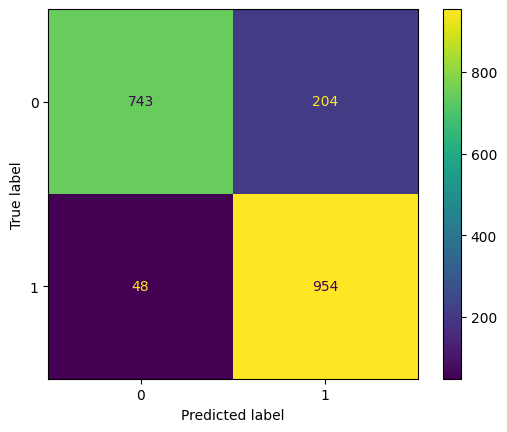

In [46]:
# Display confusion matrix
nb_cm = confusion_matrix(y_test, nb_predictions)
nb_disp = ConfusionMatrixDisplay(confusion_matrix=nb_cm)
nb_disp.plot()
print("Naive Bayes Confusion matrix")
plt.show()

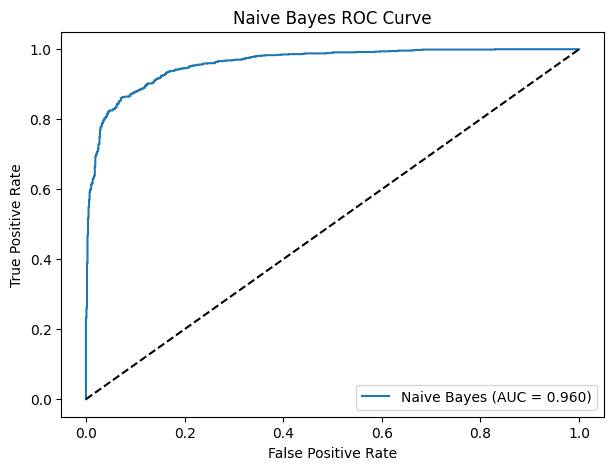

In [47]:
# ROC-AUC
nb_proba = nb_clf.predict_proba(X_test_tfidf_uni)[:, 1]
nb_fpr, nb_tpr, _ = roc_curve(y_test, nb_proba)
nb_auc = roc_auc_score(y_test, nb_proba)

plt.figure(figsize=(7, 5))
plt.plot(nb_fpr, nb_tpr, label=f'Naive Bayes (AUC = {nb_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Naive Bayes ROC Curve')
plt.legend()
plt.show()

### Try Naive Bayes again with Unigrams and Bigrams

In [48]:
# Instantiate a second Naive Bayes model
nb_clf2 = MultinomialNB()
nb_clf2.get_params()

{'alpha': 1.0, 'class_prior': None, 'fit_prior': True, 'force_alpha': True}

In [49]:
%%time

# Train model with unigram + bigram TF-IDF features
nb_clf2.fit(X_train_tfidf_bi, y_train)

CPU times: total: 0 ns
Wall time: 7.84 ms


,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [50]:
%%time

# Display accuracy
nb_predictions2 = nb_clf2.predict(X_test_tfidf_bi)
nb_accuracy2 = round(accuracy_score(y_test, nb_predictions2) * 100, 3)
print(f"Naive Bayes (Unigrams + Bigrams) Accuracy = {nb_accuracy2}%")

Naive Bayes (Unigrams + Bigrams) Accuracy = 88.917%
CPU times: total: 31.2 ms
Wall time: 0 ns


In [51]:
# Display classification report
print("Naive Bayes (Unigrams + Bigrams) Classification report")
print(classification_report(y_test, nb_predictions2))

Naive Bayes (Unigrams + Bigrams) Classification report
              precision    recall  f1-score   support

           0       0.93      0.84      0.88       947
           1       0.86      0.94      0.90      1002

    accuracy                           0.89      1949
   macro avg       0.89      0.89      0.89      1949
weighted avg       0.89      0.89      0.89      1949



Naive Bayes (Unigrams + Bigrams) Confusion matrix


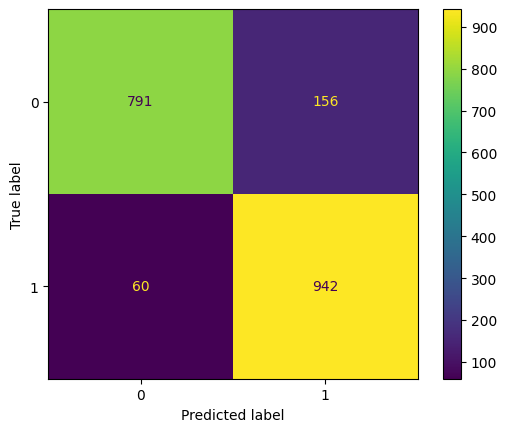

In [52]:
# Display confusion matrix
nb_cm2 = confusion_matrix(y_test, nb_predictions2)
nb_disp2 = ConfusionMatrixDisplay(confusion_matrix=nb_cm2)
nb_disp2.plot()
print("Naive Bayes (Unigrams + Bigrams) Confusion matrix")
plt.show()

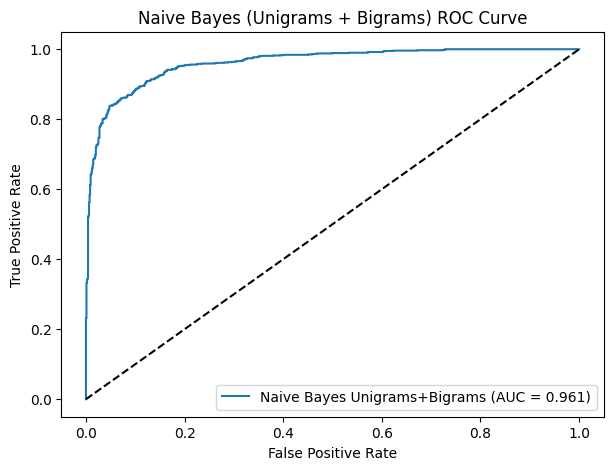

In [53]:
# ROC-AUC
nb_proba2 = nb_clf2.predict_proba(X_test_tfidf_bi)[:, 1]
nb_fpr2, nb_tpr2, _ = roc_curve(y_test, nb_proba2)
nb_auc2 = roc_auc_score(y_test, nb_proba2)

plt.figure(figsize=(7, 5))
plt.plot(nb_fpr2, nb_tpr2, label=f'Naive Bayes Unigrams+Bigrams (AUC = {nb_auc2:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Naive Bayes (Unigrams + Bigrams) ROC Curve')
plt.legend()
plt.show()

##Train Logistic Regression model

In [54]:
from sklearn.linear_model import LogisticRegression

In [55]:
# Instantiate Logistic Regression model
lr_clf = LogisticRegression(max_iter=1000, random_state=42)
lr_clf.get_params()

{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': 0.0,
 'max_iter': 1000,
 'n_jobs': None,
 'penalty': 'deprecated',
 'random_state': 42,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

In [56]:
%%time

# Train model with unigram TF-IDF features
lr_clf.fit(X_train_tfidf_uni, y_train)

CPU times: total: 15.6 ms
Wall time: 21 ms


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [57]:
# Display accuracy
lr_predictions = lr_clf.predict(X_test_tfidf_uni)
lr_accuracy = round(accuracy_score(y_test, lr_predictions) * 100, 3)
print(f"Logistic Regression Accuracy = {lr_accuracy}%")

Logistic Regression Accuracy = 90.046%


In [58]:
# Display classification report
print("Logistic Regression Classification report")
print(classification_report(y_test, lr_predictions))

Logistic Regression Classification report
              precision    recall  f1-score   support

           0       0.87      0.93      0.90       947
           1       0.93      0.87      0.90      1002

    accuracy                           0.90      1949
   macro avg       0.90      0.90      0.90      1949
weighted avg       0.90      0.90      0.90      1949



Logistic Regression Confusion matrix


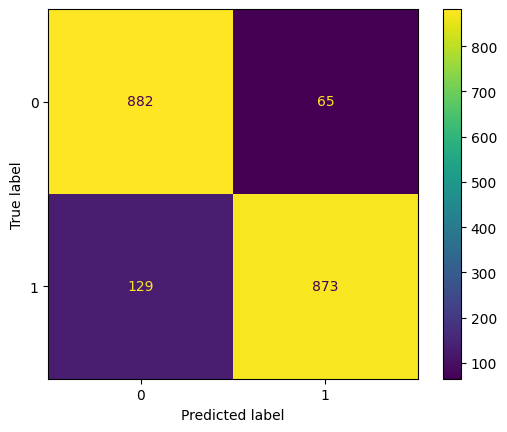

In [59]:
# Display confusion matrix
lr_cm = confusion_matrix(y_test, lr_predictions)
lr_disp = ConfusionMatrixDisplay(confusion_matrix=lr_cm)
lr_disp.plot()
print("Logistic Regression Confusion matrix")
plt.show()

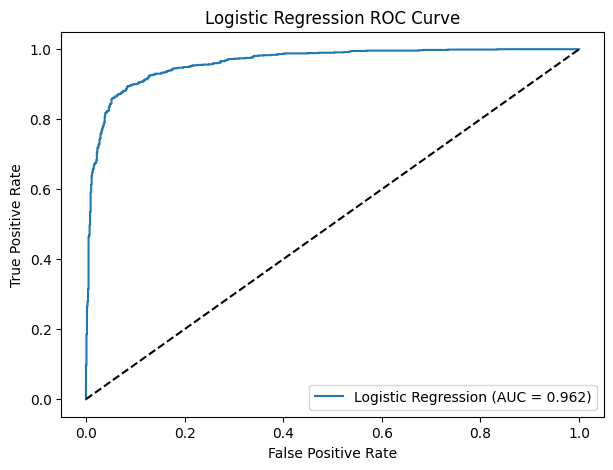

In [60]:
# ROC-AUC
lr_proba = lr_clf.predict_proba(X_test_tfidf_uni)[:, 1]
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_proba)
lr_auc = roc_auc_score(y_test, lr_proba)

plt.figure(figsize=(7, 5))
plt.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC = {lr_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression ROC Curve')
plt.legend()
plt.show()

### Try Logistic Regression again with Unigrams and Bigrams

In [61]:
# Instantiate a second Logistic Regression model
lr_clf2 = LogisticRegression(max_iter=1000, random_state=42)
lr_clf2.get_params()

{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': 0.0,
 'max_iter': 1000,
 'n_jobs': None,
 'penalty': 'deprecated',
 'random_state': 42,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

In [62]:
%%time

# Train model with unigram + bigram TF-IDF features
lr_clf2.fit(X_train_tfidf_bi, y_train)

CPU times: total: 46.9 ms
Wall time: 51.7 ms


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [63]:
%%time

# Display accuracy
lr_predictions2 = lr_clf2.predict(X_test_tfidf_bi)
lr_accuracy2 = round(accuracy_score(y_test, lr_predictions2) * 100, 3)
print(f"Logistic Regression (Unigrams + Bigrams) Accuracy = {lr_accuracy2}%")

Logistic Regression (Unigrams + Bigrams) Accuracy = 90.662%
CPU times: total: 0 ns
Wall time: 0 ns


In [64]:
# Display classification report
print("Logistic Regression (Unigrams + Bigrams) Classification report")
print(classification_report(y_test, lr_predictions2))

Logistic Regression (Unigrams + Bigrams) Classification report
              precision    recall  f1-score   support

           0       0.88      0.93      0.91       947
           1       0.93      0.88      0.91      1002

    accuracy                           0.91      1949
   macro avg       0.91      0.91      0.91      1949
weighted avg       0.91      0.91      0.91      1949



Logistic Regression (Unigrams + Bigrams) Confusion matrix


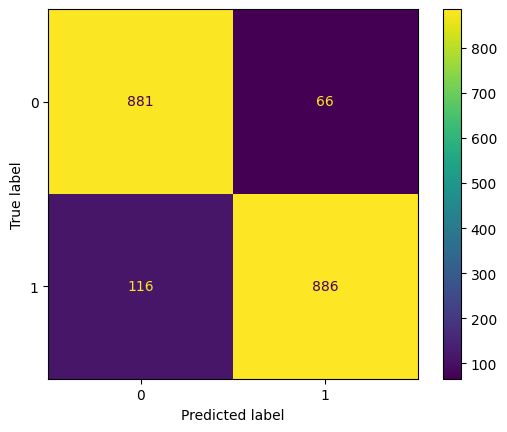

In [65]:
# Display confusion matrix
lr_cm2 = confusion_matrix(y_test, lr_predictions2)
lr_disp2 = ConfusionMatrixDisplay(confusion_matrix=lr_cm2)
lr_disp2.plot()
print("Logistic Regression (Unigrams + Bigrams) Confusion matrix")
plt.show()

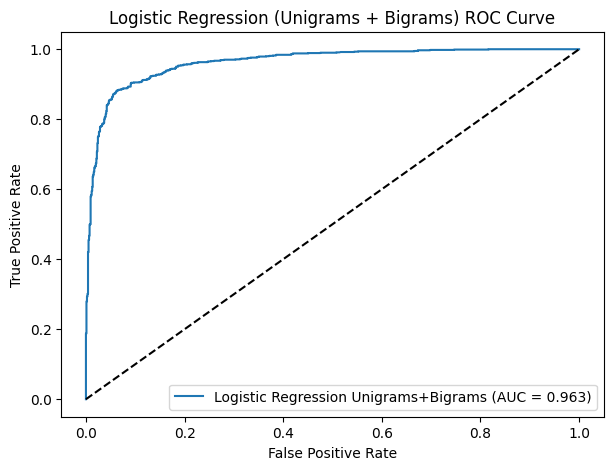

In [66]:
# ROC-AUC
lr_proba2 = lr_clf2.predict_proba(X_test_tfidf_bi)[:, 1]
lr_fpr2, lr_tpr2, _ = roc_curve(y_test, lr_proba2)
lr_auc2 = roc_auc_score(y_test, lr_proba2)

plt.figure(figsize=(7, 5))
plt.plot(lr_fpr2, lr_tpr2, label=f'Logistic Regression Unigrams+Bigrams (AUC = {lr_auc2:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression (Unigrams + Bigrams) ROC Curve')
plt.legend()
plt.show()

### Model Comparison

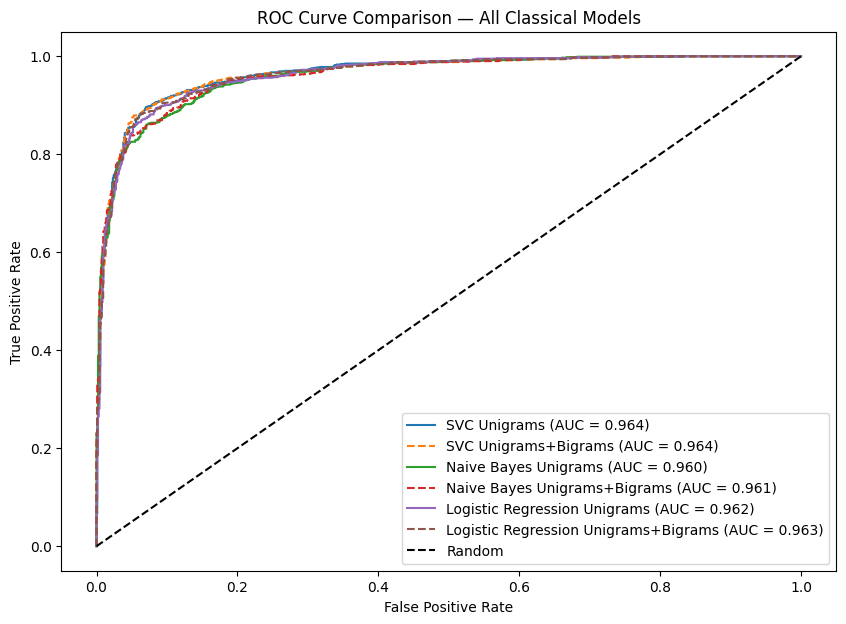

In [67]:
# Compare all models side by side
svc_proba = clf.predict_proba(X_test_tfidf_uni)[:, 1]
svc_fpr, svc_tpr, _ = roc_curve(y_test, svc_proba)
svc_auc = roc_auc_score(y_test, svc_proba)

svc_proba2 = clf2.predict_proba(X_test_tfidf_bi)[:, 1]
svc_fpr2, svc_tpr2, _ = roc_curve(y_test, svc_proba2)
svc_auc2 = roc_auc_score(y_test, svc_proba2)

plt.figure(figsize=(10, 7))
plt.plot(svc_fpr,  svc_tpr,  label=f'SVC Unigrams (AUC = {svc_auc:.3f})')
plt.plot(svc_fpr2, svc_tpr2, label=f'SVC Unigrams+Bigrams (AUC = {svc_auc2:.3f})', linestyle='--')
plt.plot(nb_fpr,   nb_tpr,   label=f'Naive Bayes Unigrams (AUC = {nb_auc:.3f})')
plt.plot(nb_fpr2,  nb_tpr2,  label=f'Naive Bayes Unigrams+Bigrams (AUC = {nb_auc2:.3f})', linestyle='--')
plt.plot(lr_fpr,   lr_tpr,   label=f'Logistic Regression Unigrams (AUC = {lr_auc:.3f})')
plt.plot(lr_fpr2,  lr_tpr2,  label=f'Logistic Regression Unigrams+Bigrams (AUC = {lr_auc2:.3f})', linestyle='--')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison — All Classical Models')
plt.legend(loc='lower right')
plt.show()

In [68]:
# Summary table — all classical model variants
svc_accuracy  = round(accuracy_score(y_test, predictions)  * 100, 3)
svc_accuracy2 = round(accuracy_score(y_test, predictions2) * 100, 3)

summary = pd.DataFrame({
    'Model':        ['SVC (Unigrams)', 'SVC (Unigrams+Bigrams)',
                     'Naive Bayes (Unigrams)', 'Naive Bayes (Unigrams+Bigrams)',
                     'Logistic Regression (Unigrams)', 'Logistic Regression (Unigrams+Bigrams)'],
    'Accuracy (%)': [svc_accuracy,  svc_accuracy2,
                     nb_accuracy,   nb_accuracy2,
                     lr_accuracy,   lr_accuracy2],
    'AUC':          [round(svc_auc, 4), round(svc_auc2, 4),
                     round(nb_auc,  4), round(nb_auc2,  4),
                     round(lr_auc,  4), round(lr_auc2,  4)]
})
summary

,Model,Accuracy (%),AUC
0,SVC (Unigrams),90.918,0.9644
1,SVC (Unigrams+Bigrams),91.021,0.9641
2,Naive Bayes (Unigrams),87.070,0.9601
3,Naive Bayes (Unigrams+Bigrams),88.917,0.9609
4,Logistic Regression (Unigrams),90.046,0.9619
5,Logistic Regression (Unigrams+Bigrams),90.662,0.9627
